# Challenge 20

Define a function f to run the following code: f = y^2−10

The assignment doesn't give any more instructions than this, so I'll assume you want a plot of the result.

## Given code:

In [1]:
# Newton-Raphson for single step with Backward Euler
def backward_euler_step(f, fprime, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # Initial guess
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(t + h, y_next)     # Was an error here, I had to add fprime as an input
        if abs(g_prime_val) < tol:  # Avoid division by zero
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  # Converged
        y_next = y_new
    return y_next

# Adaptive Backward Euler
def backward_euler_adaptive(f, fprime, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf:  # Adjust step size to not overshoot
            h = tf - t
        # Single step with h
        y_full = backward_euler_step(f, fprime, y, t, h, tol, max_iter) # Was an error here, I had to add fprime as an input
        # Two half-steps with h/2
        h_half = h / 2
        y_half_1 = backward_euler_step(f, fprime, y, t, h_half, tol, max_iter) # Same here
        y_half_2 = backward_euler_step(f, fprime, y_half_1, t + h_half, h_half, tol, max_iter) # Same here
        # Error estimation
        error = abs(y_full - y_half_2)
        # Adjust step size
        if error > tol:
            h /= 2  # Decrease step size
            continue  # Retry the step with smaller h
        elif error < tol / 2:
            h *= 2  # Increase step size for efficiency
        # Accept the step
        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)

    return np.array(t_values), np.array(y_values)

## My code

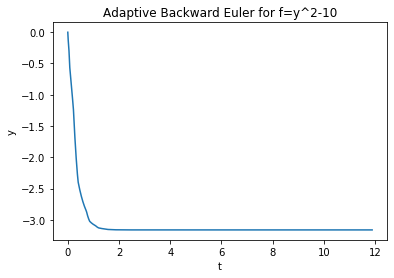

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

f = lambda t, y: y**2 - 10
fprime = lambda t, y: 2*y
y0 = 0
t0 = 0
tf = 10
h_init = 0.01

t_vals, y_vals = backward_euler_adaptive(f, fprime, y0, t0, tf, h_init)

plt.plot(t_vals, y_vals)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Adaptive Backward Euler for f=y^2-10")
plt.show()